<a href="https://colab.research.google.com/github/helloso04v/-Natural.language-processing/blob/main/%EC%9E%90%EC%97%B0%EC%96%B4%EC%B2%98%EB%A6%AC_%EA%B3%BC%EC%A0%9C%EC%A0%9C%EC%B6%9C(2023512029).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

재직중인 회사의 지속가능보고서을 분석하여 주요단어의 빈도를 추출 및 시각화 / TF-IDF 키워드 분석을 통해 핵심키워드 탐색

-빅융 / 2023512029 / 강수호

샘플 데이터 url
https://www.hlholdings.co.kr/sustainable/sustainable_2.jsp

2023년 hl홀딩스 지속가능경영보고서 ENG파일

In [2]:
# 라이브러리 설치
!pip install pdfplumber
!pip install pandas
!pip install wordcloud
!apt-get -qq install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.3 MB/s eta 0:00:00
Selecting previously unselected package fonts-nanum.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 

In [3]:
# 라이브러리 불러오기
import pdfplumber
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from collections import Counter
from google.colab import files


In [6]:
# 업로드한 파일명 입력
filename = 'sample_eng.pdf'

# 불용어 리스트 (추가 가능)
stopwords = set([
    'the', 'is', 'and', 'of', 'a', 'an', 'to', 'in', 'on', 'for', 'with', 'at', 'by',
    'from', 'as', 'that', 'this', 'it', 'be', 'are', 'or', 'was', 'were', 'but', 'not',
    'we', 'they', 'you', 'he', 'she', 'i', 'do', 'does', 'did', 'has', 'have', 'had',
    'will', 'would', 'can', 'could', 'should', 'if', 'so', 'such', 'thus', 'then', 'than', 'e', 'n', 'm', 's', 't', 'o'
])

# PDF 열고 텍스트 추출
all_text = ""

with pdfplumber.open(f'/content/{filename}') as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            all_text += text + "\n"

# 단어로 분리
words = all_text.split()

# 숫자 제거 + 불용어 제거 + 소문자 통일
filtered_words = []
for word in words:
    word_clean = re.sub(r'[^A-Za-z가-힣]', '', word)  # 영어만 남김
    word_clean = word_clean.lower()  # 소문자로 통일
    if word_clean and not word_clean.isdigit() and word_clean not in stopwords:
        filtered_words.append(word_clean)

# 단어 등장 횟수 세기
word_counts = Counter(filtered_words)

# 등장 횟수 10개 미만 제거
filtered_counts = {word: count for word, count in word_counts.items() if count >= 10}

# DataFrame으로 변환 (등장횟수 기준 내림차순 정렬)
df = pd.DataFrame(filtered_counts.items(), columns=['count', 'frequency'])
df = df.sort_values(by='frequency', ascending=False)

# 결과 출력
print(df.head(30))  # 상위 30개 단어 미리보기


             count  frequency
45      management       1464
2               hl       1085
3         holdings        806
21        business        725
38             esg        662
28           human        634
138          index        411
107         safety        407
19     performance        396
53          system        385
105         rights        373
1           report        356
108         health        344
114     governance        333
22      activities        332
49     sustainable        320
17   environmental        318
47     information        318
124           risk        283
29       resources        278
9         overview        274
287      employees        267
87             new        261
122     compliance        240
16          social        237
8            group        233
83     ecofriendly        224
78          impact        220
75      assessment        220
97           chain        219


In [7]:
# CSV로 저장
csv_path = '/content/sample_word_count.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')

# 파일 다운로드
files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# 라이브러리 불러오기
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 설정
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


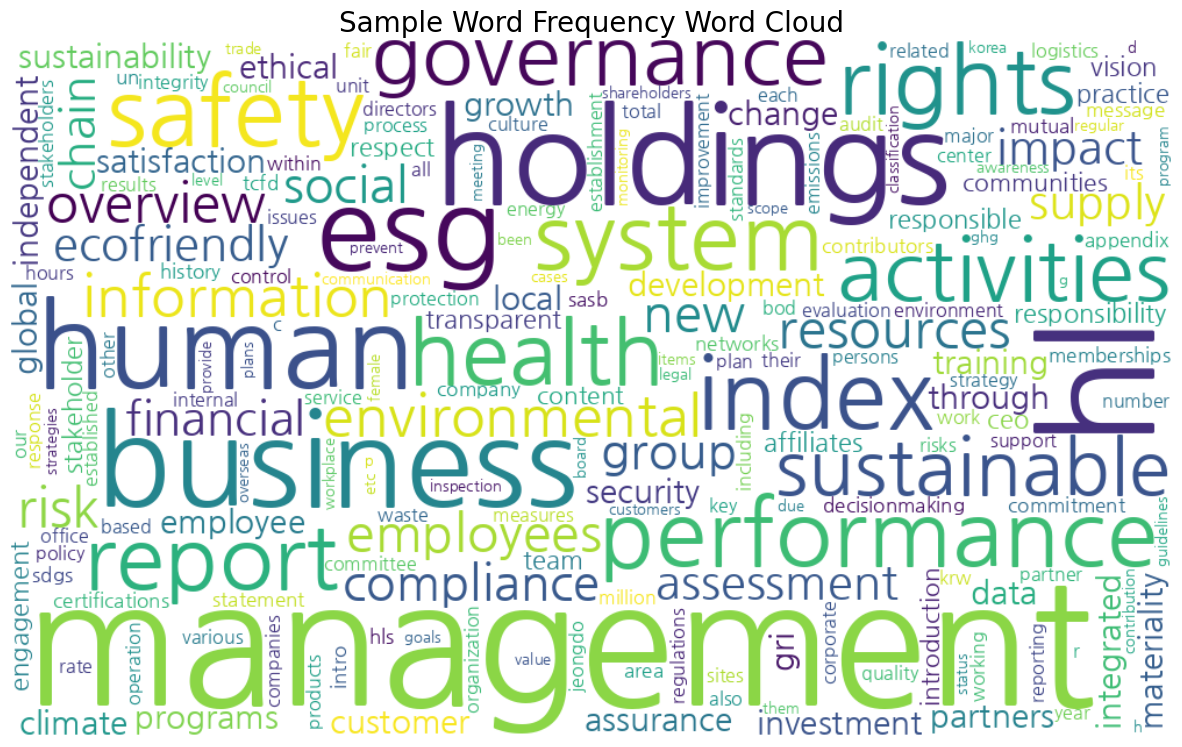

In [11]:
# 단어 빈도 dict로 변환
word_freq = dict(zip(df['count'], df['frequency']))

# 워드클라우드 객체 생성
wordcloud = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    background_color='white',
    width=1000,
    height=600
).generate_from_frequencies(word_freq)

# 시각화 출력
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Sample Word Frequency Word Cloud", fontsize=20)
plt.show()

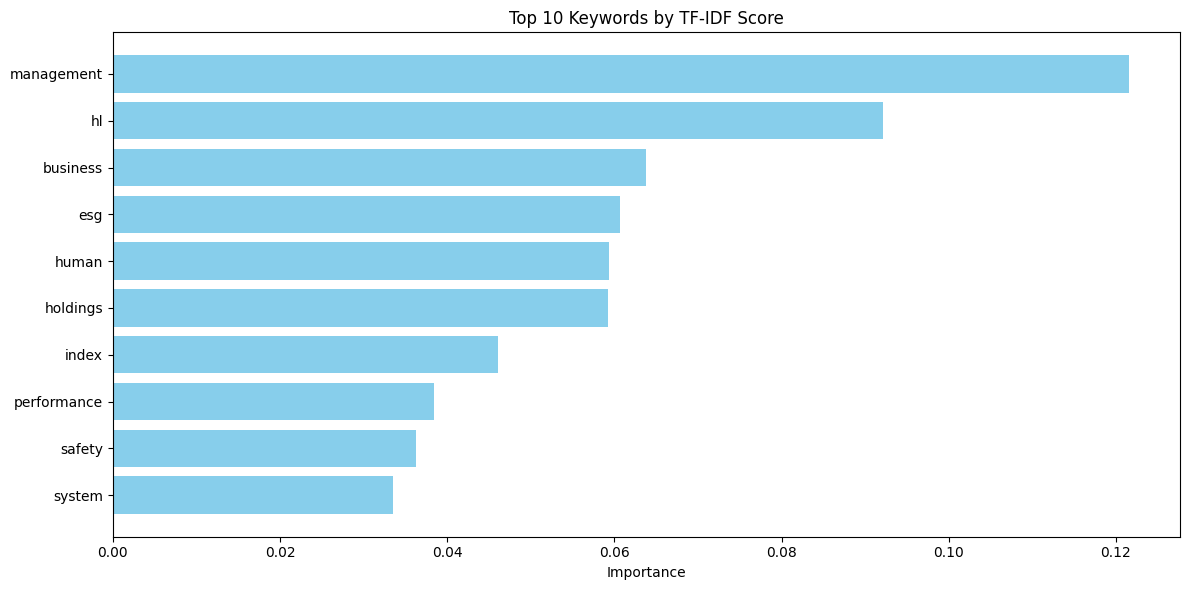

In [15]:
# 불용어 정의
english_stopwords = set([
    'the', 'is', 'and', 'of', 'a', 'an', 'to', 'in', 'on', 'for', 'with', 'at', 'by',
    'from', 'as', 'that', 'this', 'it', 'be', 'are', 'or', 'was', 'were', 'but', 'not',
    'we', 'they', 'you', 'he', 'she', 'i', 'do', 'does', 'did', 'has', 'have', 'had',
    'will', 'would', 'can', 'could', 'should', 'if', 'so', 'such', 'thus', 'then', 'than', 'e', 'n', 'm', 's', 't', 'o'
])

# PDF 텍스트 추출
filename = 'sample_eng.pdf'
all_text = ""

with pdfplumber.open(f'/content/{filename}') as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            all_text += text + "\n"

# 줄 단위 문단 분리
paragraphs = [p.strip() for p in all_text.split('\n') if p.strip()]

# TF-IDF 계산
vectorizer = TfidfVectorizer(
    stop_words=list(english_stopwords),
    max_features=10  # 상위 30개 키워드 추출
)
X = vectorizer.fit_transform(paragraphs)

# 키워드 정리
keywords = vectorizer.get_feature_names_out()
mean_scores = np.asarray(X.mean(axis=0)).ravel()
keyword_df = pd.DataFrame({'word': keywords, 'score': mean_scores})
keyword_df = keyword_df.sort_values(by='score', ascending=False)

# 시각화
plt.figure(figsize=(12, 6))
plt.barh(keyword_df['word'], keyword_df['score'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Keywords by TF-IDF Score')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

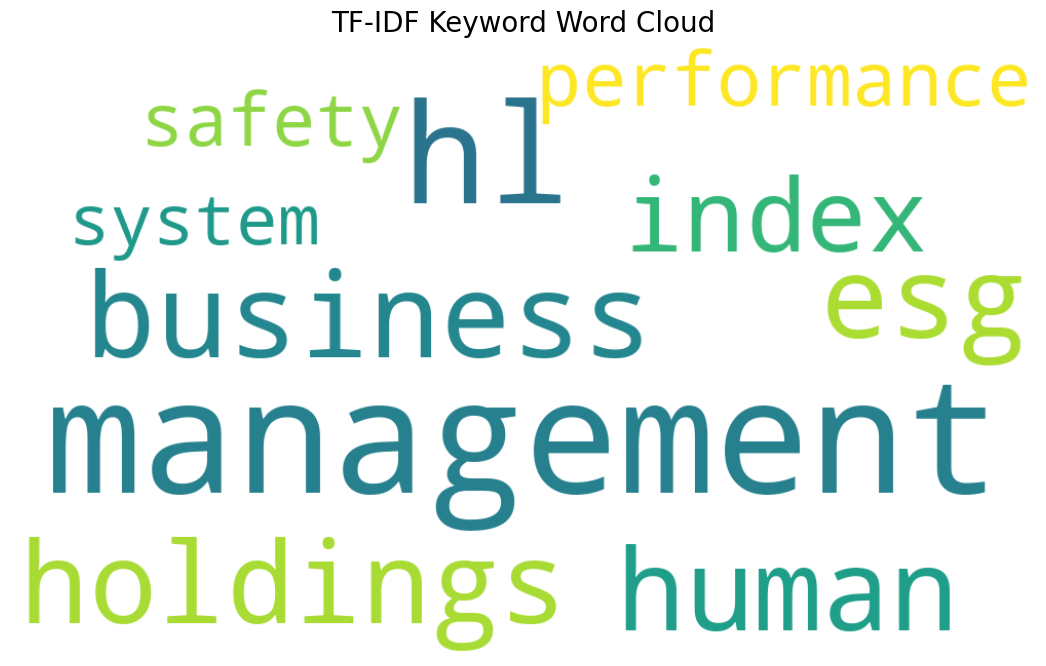

In [16]:
# 라이브러리 불러오기
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 단어:중요도 딕셔너리 생성
word_freq = dict(zip(keyword_df['word'], keyword_df['score']))

# 워드클라우드 생성
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(word_freq)

# 시각화 출력
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("TF-IDF Keyword Word Cloud", fontsize=20)
plt.show()